# How to wrap a new kernel

In [1]:
%list_kernels

Available Jupyter Kernels:
--------------------------------------------------
  python3: Python 3 (ipykernel) (python)
  pypy: Jumper Wrapper (Python 3 (ipykernel)) (python)
  r_new: Jumper Wrapper (r_new) (R)
  ir: R (R)
  scorep_jupyter: Score-P_Python (python)
  h2o_r: Jumper Wrapper (h2o_r) (R)
  jumper_wrapper: Jumper Wrapper Kernel (python)


In [1]:
%wrap_kernel ir --save r_new

Successfully wrapped kernel: ir
Hint: Refresh the page (without restarting the kernel) to enable syntax highlighting for the wrapped language.
Created permanent kernel 'r_new' that auto-wraps 'ir'.


In [1]:
%list_kernels

Available Jupyter Kernels:
--------------------------------------------------
  python3: Python 3 (ipykernel) (python)
  pypy: Jumper Wrapper (Python 3 (ipykernel)) (python)
  r_new: r_new (R)
  ir: R (R)
  scorep_jupyter: Score-P_Python (python)
  jumper_wrapper: Jumper Wrapper Kernel (python)

--------------------------------------------------
Currently wrapped kernel: ir


[1] 0.0131174

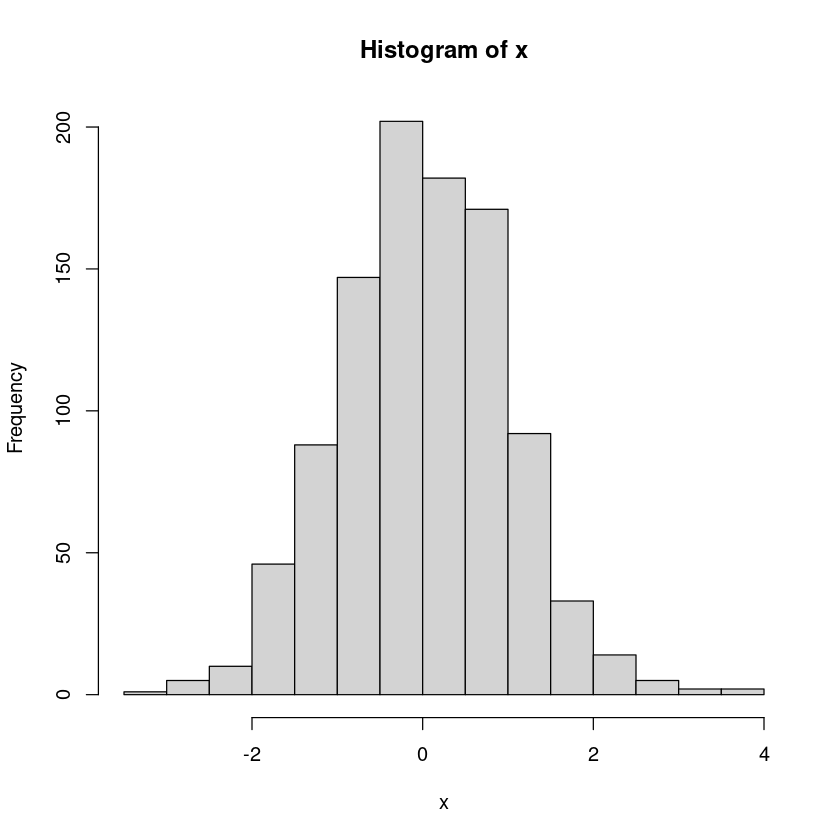

In [1]:
x <- rnorm(1000)
mean(x)
hist(x)

In [1]:
%perfmonitor_help

Available commands:
  perfmonitor_fast_setup -- quick setup: enable ipympl plots, start monitor, enable reports
  perfmonitor_help -- show this comprehensive help
  perfmonitor_resources -- show available hardware resources
  show_cell_history -- show interactive table of cell execution history
  perfmonitor_start [interval] -- start monitoring (default: 1 second)
  perfmonitor_stop -- stop monitoring
  perfmonitor_perfreport [--cell RANGE] [--level LEVEL] -- show report
  perfmonitor_plot -- interactive plot with widgets for data exploration
  perfmonitor_enable_perfreports [--level LEVEL] [--interval INTERVAL] [--text] -- enable auto-reports
  perfmonitor_disable_perfreports -- disable auto-reports
  perfmonitor_export_perfdata [--file FILE] [--level LEVEL] [--name NAME] -- export CSV; without --file pushes DataFrame (default 'perfdata_df')
  perfmonitor_export_cell_history [--file FILE] [--name NAME] -- export history to JSON/CSV; without --file pushes DataFrame (default 'cell_histo

In [1]:
%perfmonitor_fast_setup 

[JUmPER]: Enabled ipympl interactive plots
[JUmPER]: Performance monitoring started (PID: 37695, Interval: 1.0s)
[JUmPER]: Performance monitoring already running
[JUmPER]: Performance reports enabled for each cell (level: process, interval: 1.0, format: html)
[JUmPER]: Fast setup complete! Ready for interactive analysis.


In [2]:
burn_cpu <- function(seconds = 10) {
  # This function keeps the CPU busy with heavy numeric work
  # for approximately the given number of seconds.
  
  start_time <- Sys.time()
  iterations <- 0
  
  repeat {
    # Generate random matrices
    a <- matrix(runif(300 * 300), 300, 300)
    b <- matrix(runif(300 * 300), 300, 300)
    
    # Perform CPU-heavy matrix multiplication
    c <- a %*% b
    
    # Do some extra math to avoid optimization shortcuts
    d <- sum(sqrt(c))
    
    iterations <- iterations + 1
    
    # Check elapsed time
    if (as.numeric(difftime(Sys.time(), start_time, units = "secs")) >= seconds) {
      break
    }
  }
  
  cat("Completed iterations:", iterations, "\n")
}

burn_cpu(10)

Completed iterations: 626 


Metric,AVG,MIN,MAX,Total/Limit
CPU Util (Across 12 CPUs),8.41,8.32,9.16,-
Memory (GB),0.27,0.27,0.27,15.58
GPU Util (Across 1 GPUs),0.00,0.00,0.00,-
GPU Memory (GB),0.00,0.00,0.00,12.00


In [1]:
%perfmonitor_plot